     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
UPLOAD YOUR .TIF:


Saving Ghaziabad_2025_0_74.tif to Ghaziabad_2025_0_74.tif

🚀 Processing GeoTIFF (v7.3-ROADBLOCK)...
  Image: 2048x2048  Scale: 0.0195 m²/px

🏠 ROOF (conf=0.10)
    169 tiles (stride=160)
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ 'half' is deprecated and will be removed in the future. Use 'quantize' ins

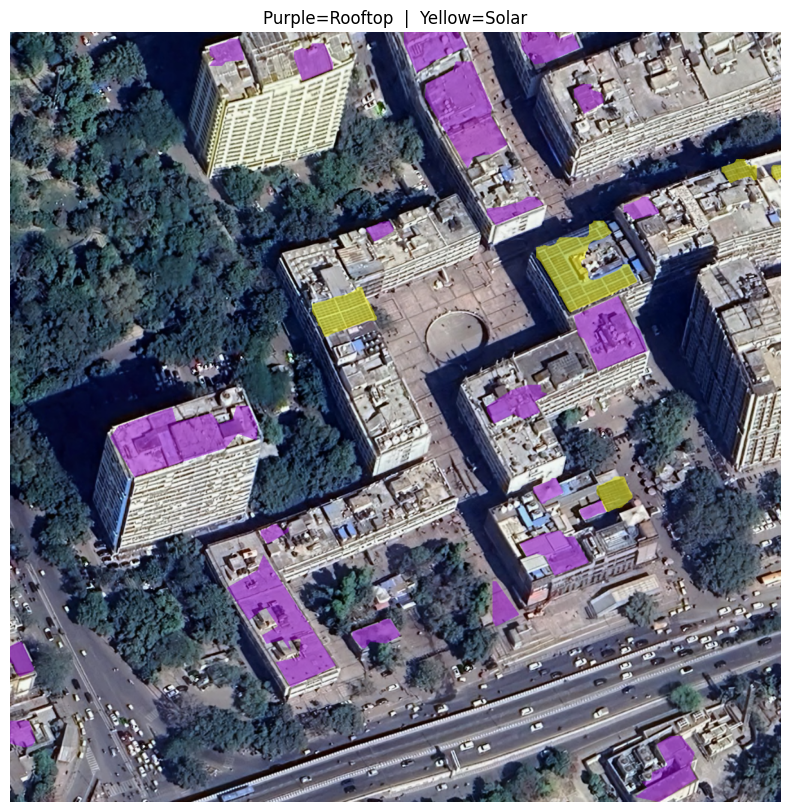


📊 SOLAR POTENTIAL REPORT
🏠 Residential Roofs  : 15 buildings | 1,397.8 m²
🏢 Commercial Roofs   : 7 buildings | 3,313.0 m²
📐 Total Roof Area    : 4,710.8 m²
☀️ Existing Solar     : 5 arrays | 1,012.7 m²

🏠 RESIDENTIAL (450W panels, 1.7m² each)
────────────────────────────────────────────────────────────
    Roof Area         : 1,397.8 m²
    Usable (70%)      : 978.5 m²
    Panels            : 489
    Capacity          : 220.1 kW
    Annual Generation : 337,337 kWh/year

🏢 COMMERCIAL (550W panels, 2.2m² each)
────────────────────────────────────────────────────────────
    Roof Area         : 3,313.0 m²
    Usable (70%)      : 2,319.1 m²
    Panels            : 927
    Capacity          : 509.9 kW
    Annual Generation : 781,600 kWh/year

⚡ COMBINED TOTALS
────────────────────────────────────────────────────────────
    Total Panels      : 1,416
    Total Capacity    : 729.9 kW
    Total Generation  : 1,118,937 kWh/year


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
# =======================================================================
# INFERENCE v7.3-ROADBLOCK — V7.3 EXACT + ROAD STRIP REMOVAL
# =======================================================================
!pip install ultralytics
import os, gc, cv2, csv, zipfile, shutil, warnings
import numpy as np, rasterio, geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from shapely.geometry import Polygon
import torch
from ultralytics import YOLO
from google.colab import files
from geopy.distance import geodesic
from rasterio.warp import transform as transform_coords
warnings.filterwarnings("ignore")

USE_HALF = torch.cuda.is_available()
BASE = "/content"
UPLOAD_DIR = f"{BASE}/uploads"
os.makedirs(UPLOAD_DIR, exist_ok=True)

BEST_ROOF_PT  = f"{BASE}/best_roof.pt"
BEST_SOLAR_PT = f"{BASE}/best_solar.pt"

MIN_VIABLE_ROOF_SQM = 15.0
COMMERCIAL_THRESHOLD_SQM = 200.0

def clear_ram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

assert os.path.exists(BEST_ROOF_PT), "Upload best_roof.pt first!"
assert os.path.exists(BEST_SOLAR_PT), "Upload best_solar.pt first!"

def run_dual_inference_on_tif(img_path, panel_conf=0.20, roof_conf=0.45):
    print("\n🚀 Processing GeoTIFF (v7.3-ROADBLOCK)...")
    raster_transform, crs, scale_sqm = None, None, 0.0

    with rasterio.open(img_path) as src:
        crs = src.crs
        raster_transform = src.transform
        if crs:
            try:
                bounds = src.bounds
                lons, lats = transform_coords(crs, 'epsg:4326', [bounds.left, bounds.right], [bounds.bottom, bounds.top])
                width_m = geodesic((lats[0], lons[0]), (lats[0], lons[1])).meters
                height_m = geodesic((lats[0], lons[0]), (lats[1], lons[0])).meters
                scale_sqm = (width_m / src.width) * (height_m / src.height)
            except Exception as e:
                print(f"    Warning: Could not calculate scale - {e}")

        bands = min(src.count, 3)
        img_rgb = np.transpose(src.read(list(range(1, bands + 1))), (1, 2, 0))
        if bands == 1:
            img_rgb = np.repeat(img_rgb, 3, axis=-1)
        if img_rgb.dtype != np.uint8:
            img_rgb = img_rgb.astype(np.float32)
            lo, hi = np.percentile(img_rgb, 2), np.percentile(img_rgb, 98)
            img_rgb = np.clip((img_rgb - lo) / (hi - lo), 0, 1) * 255.0 if hi > lo else np.clip(img_rgb, 0, 255)
            img_rgb = img_rgb.astype(np.uint8)
        img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        del img_rgb

    h, w = img_bgr.shape[:2]
    print(f"  Image: {w}x{h}  Scale: {scale_sqm:.4f} m²/px")

    tmp = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.int16)
    veg_mask = (tmp[:,:,1] > tmp[:,:,0] + 15) & (tmp[:,:,1] > tmp[:,:,2] + 15)
    del tmp

    def sweep(model_path, conf, min_area_sqm, vote_thresh, min_edge,
              shape_filter, shape_thresh, max_aspect,
              stride, tile, close_k, open_k,
              batch_size=8, restrict_mask=None, is_solar=False):

        model = YOLO(model_path)
        votes  = np.zeros((h, w), dtype=np.uint16)
        counts = np.zeros((h, w), dtype=np.uint16)

        coords = []
        for y in range(0, h, stride):
            for x in range(0, w, stride):
                ch, cw = min(tile, h-y), min(tile, w-x)
                if ch <= 64 or cw <= 64: continue
                if not is_solar and veg_mask[y:y+ch, x:x+cw].mean() >= 0.90: continue
                if restrict_mask is not None and not restrict_mask[y:y+ch, x:x+cw].any(): continue
                coords.append((x, y, cw, ch))

        print(f"    {len(coords)} tiles (stride={stride})")

        for i in range(0, len(coords), batch_size):
            batch = coords[i:i+batch_size]
            crops = [img_bgr[y:y+ch, x:x+cw] for x,y,cw,ch in batch]
            results = model.predict(crops, conf=conf, iou=0.5, imgsz=tile,
                                    retina_masks=False, verbose=False, half=USE_HALF)
            for (x,y,cw,ch), res in zip(batch, results):
                counts[y:y+ch, x:x+cw] += 1
                if res.masks is not None:
                    for cls, cf, mask in zip(res.boxes.cls.cpu().numpy(),
                                             res.boxes.conf.cpu().numpy(),
                                             res.masks.data.cpu().numpy()):
                        if int(cls)==0 and cf>=conf:
                            m = cv2.resize(mask,(cw,ch),interpolation=cv2.INTER_NEAREST)>0.5
                            if not is_solar:
                                m &= ~veg_mask[y:y+ch, x:x+cw]
                            votes[y:y+ch, x:x+cw] += m.astype(np.uint16)
            del results, crops
            clear_ram()

        v = counts > 0
        ratio = np.zeros((h,w), dtype=np.float32)
        ratio[v] = votes[v] / counts[v]
        binary = (ratio >= vote_thresh).astype(np.uint8)

        if close_k > 0:
            binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE,
                        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_k, close_k)))
        if open_k > 0:
            binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN,
                        cv2.getStructuringElement(cv2.MORPH_RECT, (open_k, open_k)))

        min_px = int(min_area_sqm / scale_sqm) if scale_sqm > 0 else 50
        inst = []
        contours,_ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        n = {"raw":len(contours),"area":0,"aspect":0,"edge":0,"shape":0,"colour":0}

        for cnt in contours:
            if cv2.contourArea(cnt) < min_px: continue
            n["area"] += 1

            bx,by,bw,bh = cv2.boundingRect(cnt)
            ar = max(bw,bh)/max(min(bw,bh),1)
            if max_aspect > 0 and ar > max_aspect: continue
            n["aspect"] += 1

            m = np.zeros((h,w), dtype=np.uint8)
            cv2.drawContours(m,[cnt],-1,1,-1)

            if min_edge > 0:
                ys,xs = np.where(m)
                if not len(ys): continue
                y1,y2,x1,x2 = ys.min(),ys.max(),xs.min(),xs.max()
                e = cv2.Canny(cv2.cvtColor(img_bgr[y1:y2+1,x1:x2+1],cv2.COLOR_BGR2GRAY),50,150)
                er = np.count_nonzero(e & m[y1:y2+1,x1:x2+1]) / max(np.count_nonzero(m[y1:y2+1,x1:x2+1]),1)
                if er < min_edge: continue
            n["edge"] += 1

            if shape_filter:
                ha = cv2.contourArea(cv2.convexHull(cnt))
                if ha > 0 and cv2.contourArea(cnt)/ha < shape_thresh: continue
            n["shape"] += 1

            ys,xs = np.where(m)
            if len(ys):
                y1,y2,x1,x2 = ys.min(),ys.max(),xs.min(),xs.max()
                bp = img_bgr[y1:y2+1,x1:x2+1][m[y1:y2+1,x1:x2+1].astype(bool)]
                if len(bp):
                    hsv = cv2.cvtColor(bp.reshape(-1,1,3),cv2.COLOR_BGR2HSV).reshape(-1,3)
                    mh,ms,mv = float(np.median(hsv[:,0])), float(np.median(hsv[:,1])), float(np.median(hsv[:,2]))
                    if 35<=mh<=85 and ms>40: continue
            n["colour"] += 1
            inst.append((cnt, m.astype(bool)))

        print(f"    {n['raw']}→{n['area']}→{n['aspect']}→{n['edge']}→{n['shape']}→{n['colour']} = {len(inst)}")
        del votes, counts, binary, model
        clear_ram()
        return inst

    # ════════════════════════════════════════════════════
    # ROOF SWEEP (v7.3 Exact Logic & Params)
    # ════════════════════════════════════════════════════
    print("\n🏠 ROOF (conf=%.2f)" % roof_conf)
    roofs = sweep(BEST_ROOF_PT, conf=roof_conf,
                  min_area_sqm=25.0,
                  vote_thresh=0.30,
                  min_edge=0.01,
                  shape_filter=True,
                  shape_thresh=0.50,
                  max_aspect=4.0,
                  stride=160, tile=640,
                  close_k=21, open_k=3,
                  is_solar=False)
    print(f"    ✅ {len(roofs)} roofs (raw)")

    # POST-PROCESS #1: STRAIGHTEN BOUNDARIES
    straightened = []
    for cnt, m in roofs:
        peri = cv2.arcLength(cnt, True)
        cnt_s = cv2.approxPolyDP(cnt, 0.012 * peri, True)
        if len(cnt_s) < 4: cnt_s = cnt
        m_s = np.zeros((h,w), dtype=np.uint8)
        cv2.drawContours(m_s, [cnt_s], -1, 1, -1)
        straightened.append((cnt_s, m_s.astype(bool)))
    roofs = straightened
    print(f"    ✅ {len(roofs)} roofs (straightened)")

    # POST-PROCESS #2: EXCLUDE ROOFS WITH INTERNAL STRUCTURES
    clean = []
    for cnt, m in roofs:
        m_u8 = m.astype(np.uint8)
        interior = cv2.erode(m_u8, cv2.getStructuringElement(cv2.MORPH_RECT,(7,7)))
        ipx = np.count_nonzero(interior)
        if ipx < 20:
            clean.append((cnt, m)); continue
        ys,xs = np.where(interior)
        y1,y2,x1,x2 = int(ys.min()),int(ys.max()),int(xs.min()),int(xs.max())
        edges = cv2.Canny(cv2.cvtColor(img_bgr[y1:y2+1,x1:x2+1],cv2.COLOR_BGR2GRAY),50,150)
        ratio = np.count_nonzero(edges & interior[y1:y2+1,x1:x2+1]) / ipx
        if ratio < 0.15:
            clean.append((cnt, m))
    print(f"    ✅ {len(clean)} roofs (structures excluded, removed {len(roofs)-len(clean)})")
    roofs = clean

    # POST-PROCESS #3: MIN VIABLE AREA
    if scale_sqm > 0:
        min_vpx = int(MIN_VIABLE_ROOF_SQM / scale_sqm)
        viable = [(c,m) for c,m in roofs if np.count_nonzero(m) >= min_vpx]
        print(f"    ✅ {len(viable)} viable roofs (≥{MIN_VIABLE_ROOF_SQM}m², removed {len(roofs)-len(viable)})")
        roofs = viable

    # ════════════════════════════════════════════════════
    # POST-PROCESS #4: ROAD BLOCKER
    # ════════════════════════════════════════════════════
    before_road = len(roofs)
    road_clean = []
    for cnt, m in roofs:
        (rw, rh) = cv2.minAreaRect(cnt)[1]
        if min(rw, rh) < 1:
            continue
        aspect = max(rw, rh) / min(rw, rh)
        if aspect > 3.2:
            continue
        rect_score = cv2.contourArea(cnt) / max(rw * rh, 1)
        if rect_score < 0.55:
            continue
        road_clean.append((cnt, m))
    roofs = road_clean
    print(f"    ✅ {len(roofs)} roofs (ROAD BLOCKER, removed {before_road - len(roofs)} roads/strips)")

    # ════════════════════════════════════════════════════
    # SOLAR SWEEP
    # ════════════════════════════════════════════════════
    print("\n☀️ SOLAR (conf=%.2f)" % panel_conf)
    panels_raw = sweep(BEST_SOLAR_PT, conf=panel_conf,
                       min_area_sqm=8.0,  vote_thresh=0.25,
                       min_edge=0.04,     shape_filter=False,
                       shape_thresh=0.0,  max_aspect=0,
                       stride=256, tile=512,
                       close_k=25, open_k=3,
                       restrict_mask=None,
                       is_solar=True)

    panels = []
    for cnt,m in panels_raw:
        ys,xs = np.where(m)
        if not len(ys): continue
        bp = img_bgr[ys.min():ys.max()+1, xs.min():xs.max()+1][m[ys.min():ys.max()+1, xs.min():xs.max()+1]]
        if not len(bp): continue
        hsv = cv2.cvtColor(bp.reshape(-1,1,3),cv2.COLOR_BGR2HSV).reshape(-1,3)
        mh, ms, mv = float(np.median(hsv[:,0])), float(np.median(hsv[:,1])), float(np.median(hsv[:,2]))
        if mv > 180: continue
        if 15 <= mh <= 40 and ms > 50: continue
        panels.append((cnt,m))
    print(f"    ✅ {len(panels)} panels")

    pmask = np.zeros((h,w),dtype=bool)
    for _,m in panels: pmask |= m
    roofs = [(c, m & ~pmask) for c,m in roofs if np.count_nonzero(m & ~pmask)>0]

    # ════════════════════════════════════════════════════
    # CLASSIFY & DRAW
    # ════════════════════════════════════════════════════
    res_roofs, com_roofs = [], []
    for c, m in roofs:
        area = np.count_nonzero(m) * scale_sqm
        if area >= COMMERCIAL_THRESHOLD_SQM: com_roofs.append((c, m))
        else: res_roofs.append((c, m))

    print(f"\n    🏠 {len(res_roofs)} residential (<{COMMERCIAL_THRESHOLD_SQM}m²)")
    print(f"    🏢 {len(com_roofs)} commercial (≥{COMMERCIAL_THRESHOLD_SQM}m²)")

    out = img_bgr.copy()
    for _,m in res_roofs: out[m] = (out[m]//2) + (np.array([211,0,148],dtype=np.uint8)//2)
    for _,m in com_roofs: out[m] = (out[m]//2) + (np.array([211,0,148],dtype=np.uint8)//2)
    for _,m in panels:    out[m] = (out[m]//2) + (np.array([0,255,255],dtype=np.uint8)//2)

    plt.figure(figsize=(14,10))
    plt.imshow(cv2.cvtColor(cv2.resize(out,(int(1200*(w/h)),1200)),cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Purple=Rooftop  |  Yellow=Solar", fontsize=12)
    plt.show()

    # ════════════════════════════════════════════════════
    # PANEL MATH
    # ════════════════════════════════════════════════════
    res_roof_sqm = sum(np.count_nonzero(m) for _,m in res_roofs) * scale_sqm
    com_roof_sqm = sum(np.count_nonzero(m) for _,m in com_roofs) * scale_sqm
    total_roof_sqm = res_roof_sqm + com_roof_sqm
    solar_sqm = sum(np.count_nonzero(m) for _,m in panels) * scale_sqm

    res_usable = res_roof_sqm * 0.70
    com_usable = com_roof_sqm * 0.70
    res_panel_area = 2.0;  res_panel_kw = 0.45
    com_panel_area = 2.5;  com_panel_kw = 0.55
    sun_hours = 4.2

    res_panels_fit = int(res_usable / res_panel_area)
    com_panels_fit = int(com_usable / com_panel_area)
    res_kw = res_panels_fit * res_panel_kw
    com_kw = com_panels_fit * com_panel_kw
    res_kwh_y = res_kw * sun_hours * 365
    com_kwh_y = com_kw * sun_hours * 365
    total_kw = res_kw + com_kw
    total_kwh_y = res_kwh_y + com_kwh_y

    print(f"\n{'='*60}")
    print(f"📊 SOLAR POTENTIAL REPORT")
    print(f"{'='*60}")
    print(f"🏠 Residential Roofs  : {len(res_roofs):,} buildings | {res_roof_sqm:,.1f} m²")
    print(f"🏢 Commercial Roofs   : {len(com_roofs):,} buildings | {com_roof_sqm:,.1f} m²")
    print(f"📐 Total Roof Area    : {total_roof_sqm:,.1f} m²")
    print(f"☀️ Existing Solar     : {len(panels)} arrays | {solar_sqm:,.1f} m²")
    print(f"{'='*60}")
    print(f"\n🏠 RESIDENTIAL (450W panels, 1.7m² each)")
    print(f"{'─'*60}")
    print(f"    Roof Area         : {res_roof_sqm:,.1f} m²")
    print(f"    Usable (70%)      : {res_usable:,.1f} m²")
    print(f"    Panels            : {res_panels_fit:,}")
    print(f"    Capacity          : {res_kw:,.1f} kW")
    print(f"    Annual Generation : {res_kwh_y:,.0f} kWh/year")
    print(f"\n🏢 COMMERCIAL (550W panels, 2.2m² each)")
    print(f"{'─'*60}")
    print(f"    Roof Area         : {com_roof_sqm:,.1f} m²")
    print(f"    Usable (70%)      : {com_usable:,.1f} m²")
    print(f"    Panels            : {com_panels_fit:,}")
    print(f"    Capacity          : {com_kw:,.1f} kW")
    print(f"    Annual Generation : {com_kwh_y:,.0f} kWh/year")
    print(f"\n⚡ COMBINED TOTALS")
    print(f"{'─'*60}")
    print(f"    Total Panels      : {res_panels_fit + com_panels_fit:,}")
    print(f"    Total Capacity    : {total_kw:,.1f} kW")
    print(f"    Total Generation  : {total_kwh_y:,.0f} kWh/year")
    print(f"{'='*60}")

    # ════════════════════════════════════════════════════
    # EXPORT
    # ════════════════════════════════════════════════════
    vd = Path(f"{UPLOAD_DIR}/vectors")
    if vd.exists(): shutil.rmtree(vd)
    vd.mkdir(exist_ok=True)

    with open(f"{vd}/detected_gps.csv","w",newline="") as f:
        w2 = csv.writer(f)
        w2.writerow(["Type","Category","Area_sqm","Lat","Lon"])
        for name, data, cat in [
            ("rooftop", res_roofs, "residential"),
            ("rooftop", com_roofs, "commercial"),
            ("solar_panel", panels, "existing")
        ]:
            recs = []
            for cnt,mask in data:
                try:
                    poly = Polygon([(raster_transform*(p[0][0],p[0][1])) if raster_transform else (p[0][0],-p[0][1]) for p in cnt]).buffer(0)
                    asqm = np.count_nonzero(mask)*scale_sqm
                    cl,ct = (None,None)
                    if crs:
                        la,lo2 = transform_coords(crs,'epsg:4326',[poly.centroid.x],[poly.centroid.y])
                        cl,ct = la[0],lo2[0]
                    recs.append({"area_sqm":round(asqm,2),"category":cat,"center_lat":ct,"center_lon":cl,"geometry":poly})
                    if ct: w2.writerow([name,cat,round(asqm,2),round(ct,6),round(cl,6)])
                except: pass
            if recs:
                gdf = gpd.GeoDataFrame(recs,geometry="geometry")
                if crs: gdf.set_crs(crs,inplace=True,allow_override=True)
                gdf.to_file(f"{vd}/{name}_{cat}.shp")

    cv2.imwrite(f"{vd}/overlay.png", out)
    del out; clear_ram()
    with zipfile.ZipFile(f"{UPLOAD_DIR}/vectors.zip",'w',zipfile.ZIP_DEFLATED) as zf:
        for f2 in vd.glob("*"): zf.write(f2,f2.name)
    files.download(f"{UPLOAD_DIR}/vectors.zip")

# =======================================================================
print("UPLOAD YOUR .TIF:")
tif_upload = files.upload()
if tif_upload:
    tn = list(tif_upload.keys())[0]
    os.rename(tn, f"{UPLOAD_DIR}/{tn}")
    run_dual_inference_on_tif(f"{UPLOAD_DIR}/{tn}", panel_conf=0.30, roof_conf=0.10)